## Cleaner Code Than 4-conditional-graph-exercise

It was an exercise of conecting multi edges and conditional edges in 4-conditional-graph-exercise.ipynb and in that way, the code was made inefficiently. So This is a more practical and cleaner way to implement the app using reusable nodes.

In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

## State

In [2]:
class AgentState(TypedDict):
    ### Inputs
    num1: int
    operation1: Literal["+", "-"]
    num2: int

    num3: int
    operation2: Literal["+", "-"]

    ### Outputs
    mid_result: int
    final_result: int

    ### Reusable Operation Node
    left: int
    right: int
    op: Literal["+", "-"]
    out_key: Literal["mid_result", "final_result"]

## Nodes

In [3]:
def op_stage1(state: AgentState) -> AgentState:
    """
    Node for operational stage 1
    """
    state["left"] = state["num1"]
    state["right"] = state["num2"]
    state["op"] = state["operation1"]
    state["out_key"] = "mid_result"

    return state

In [4]:
def op_stage2(state: AgentState) -> AgentState:
    """
    Node for operational stage 2
    """
    state["left"] = state["mid_result"]
    state["right"] = state["num3"]
    state["op"] = state["operation2"]
    state["out_key"] = "final_result"

    return state

In [5]:
def apply_op_node(state: AgentState) -> AgentState:
    """
    Reusable math operation, used for op_state1 and 2 node
    """

    if state["op"] == "+":
        state[state["out_key"]] = state["left"] + state["right"]
    elif state["op"] == "-":
        state[state["out_key"]] = state["left"] - state["right"]
    else:
        raise ValueError(f"Invalid op: {state["op"]}")

    return state

## Graph

In [23]:
graph = StateGraph(AgentState)

graph.add_node("stage1", op_stage1)
graph.add_node("op1", apply_op_node)

graph.add_node("stage2", op_stage2) 
graph.add_node("op2", apply_op_node)

graph.add_edge(START, "stage1")
graph.add_edge("stage1", "op1")

graph.add_edge("op1", "stage2")
graph.add_edge("stage2", "op2")

graph.add_edge("op2", END)

app = graph.compile()

## Graph Display

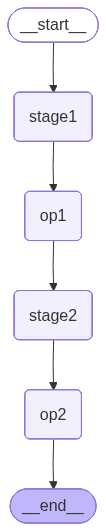

In [24]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

## Run

In [22]:
result = app.invoke(
    {
        "num1": 10,
        "operation1": "-",
        "num2": 5,
        "num3": 7,
        "operation2": "+",
    }, 
    config= {"configurable": {"recursion_limit": 10000}}
)

result["final_result"]

12